# Geographic Analysis
This notebook analyzes review volume, ratings, sentiment, and themes across provinces and districts.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)
plt.style.use("seaborn-v0_8")

In [2]:
# Configuration
INPUT_FILE = os.getenv("INPUT_FILE", "Processed_Reviews.csv")
MIN_REVIEWS_REGION = 20

In [3]:
# Load dataset
df = pd.read_csv(INPUT_FILE)

print(f"Loaded: {INPUT_FILE}")
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

required_cols = ["Province", "District", "Rating"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

Loaded: Processed_Reviews.csv
Shape: (16156, 41)
Columns:
['Location_Name', 'Located_City', 'Province', 'District', 'Location_Type', 'User_Locale', 'User_Country', 'User_Region', 'Travel_Date_Month', 'Travel_Date_Year', 'Published_Date_Month', 'Published_Date_Year', 'User_Contributions', 'Rating', 'Helpful_Votes', 'Review_Length', 'Title_Length', 'Rating_Class', 'Review_Delay_Days', 'Combined_Text', 'Combined_Sentiment', 'Sentiment_Score', 'Emotion', 'Dominant_Topic', 'Topic_Probability', 'Topic_Keywords', 'Review_Theme', 'Sentiment_Rating_Gap', 'Length_Bucket', 'Has_Helpful_Votes', 'Helpfulness_Ratio', 'Helpful_Bucket', 'Reviewer_Experience', 'Sentiment_Numeric', 'Location_Avg_Rating', 'Location_Review_Count', 'Location_Sentiment_Mean', 'Rank_By_Rating', 'Rank_By_Popularity', 'Popularity_Quality_Gap', 'Review_Quality_Score']


In [4]:
# Review distribution by province and district
print("=== Review Count by Province ===")
province_counts = df["Province"].value_counts()
print(province_counts)

print("\n=== Top Districts by Review Count ===")
district_counts = df["District"].value_counts().head(15)
print(district_counts)

=== Review Count by Province ===
Province
Central Province          5252
North Central Province    3171
Southern Province         2648
Western Province          1890
Eastern Province          1162
Uva Province              1040
Sabaragamuwa Province      518
Northern Province          475
Name: count, dtype: int64

=== Top Districts by Review Count ===
District
Anuradhapura    2838
Kandy           2342
Nuwara Eliya    2221
Galle           1823
Colombo         1171
Matale           763
Jaffna           475
Badulla          471
Trincomalee      409
Haputale         409
Nilaveli         371
Pinnawala        369
Polonnaruwa      333
Beruwala         292
Ampara           222
Name: count, dtype: int64


In [5]:
# Province-level rating analysis
province_rating_summary = (
    df.groupby("Province")
      .agg(Review_Count=("Rating", "count"), Avg_Rating=("Rating", "mean"), Rating_STD=("Rating", "std"))
      .reset_index()
)
province_rating_summary["Rating_STD"] = province_rating_summary["Rating_STD"].fillna(0)
province_rating_summary = province_rating_summary[
    province_rating_summary["Review_Count"] >= MIN_REVIEWS_REGION
].sort_values(by="Avg_Rating", ascending=False)

print(f"=== Province Rating Summary (min {MIN_REVIEWS_REGION} reviews) ===")
print(province_rating_summary)

=== Province Rating Summary (min 20 reviews) ===
                 Province  Review_Count  Avg_Rating  Rating_STD
5       Southern Province          2648    4.408988    0.900838
2  North Central Province          3171    4.310943    0.855380
1        Eastern Province          1162    4.215146    1.028539
6            Uva Province          1040    4.170192    1.031214
3       Northern Province           475    4.141053    0.931798
0        Central Province          5252    4.073115    0.995316
7        Western Province          1890    3.932275    1.150260
4   Sabaragamuwa Province           518    3.781853    1.399329


In [6]:
# District-level rating analysis
district_rating_summary = (
    df.groupby("District")
      .agg(Review_Count=("Rating", "count"), Avg_Rating=("Rating", "mean"), Rating_STD=("Rating", "std"))
      .reset_index()
)
district_rating_summary["Rating_STD"] = district_rating_summary["Rating_STD"].fillna(0)
district_rating_summary = district_rating_summary[
    district_rating_summary["Review_Count"] >= MIN_REVIEWS_REGION
].sort_values(by="Avg_Rating", ascending=False)

print(f"=== District Rating Summary (min {MIN_REVIEWS_REGION} reviews) ===")
print(district_rating_summary.head(20))

=== District Rating Summary (min 20 reviews) ===
         District  Review_Count  Avg_Rating  Rating_STD
21       Tangalle           132    4.992424    0.087039
24      Weligatta           189    4.698413    0.635014
20      Ratnapura           149    4.677852    0.755775
10       Kalkudah           160    4.562500    0.688518
13       Koslanda            86    4.488372    0.698640
22  Tissamaharama            91    4.428571    0.652225
19    Polonnaruwa           333    4.423423    0.786362
6           Galle          1823    4.360943    0.927829
5        Deniyaya           196    4.331633    0.898557
1    Anuradhapura          2838    4.297745    0.862284
3        Beruwala           292    4.284247    0.918327
23    Trincomalee           409    4.281174    0.897525
15         Matara           217    4.267281    1.046373
2         Badulla           471    4.259023    0.920683
14         Matale           763    4.163827    1.032619
9          Jaffna           475    4.141053    0.931798

In [7]:
# Province-level sentiment analysis
if "Sentiment_Numeric" in df.columns:
    province_sentiment_summary = (
        df.groupby("Province")
          .agg(Review_Count=("Sentiment_Numeric", "count"), Avg_Sentiment=("Sentiment_Numeric", "mean"))
          .reset_index()
    )
    province_sentiment_summary = province_sentiment_summary[
        province_sentiment_summary["Review_Count"] >= MIN_REVIEWS_REGION
    ].sort_values(by="Avg_Sentiment", ascending=False)
    print(f"=== Province Sentiment Summary (min {MIN_REVIEWS_REGION} reviews) ===")
    print(province_sentiment_summary)
else:
    province_sentiment_summary = None

=== Province Sentiment Summary (min 20 reviews) ===
                 Province  Review_Count  Avg_Sentiment
5       Southern Province          2648       0.754154
6            Uva Province          1040       0.719231
0        Central Province          5252       0.716299
2  North Central Province          3171       0.706717
1        Eastern Province          1162       0.693632
3       Northern Province           475       0.648421
7        Western Province          1890       0.587831
4   Sabaragamuwa Province           518       0.418919


In [8]:
# District-level sentiment analysis
if "Sentiment_Numeric" in df.columns:
    district_sentiment_summary = (
        df.groupby("District")
          .agg(Review_Count=("Sentiment_Numeric", "count"), Avg_Sentiment=("Sentiment_Numeric", "mean"))
          .reset_index()
    )
    district_sentiment_summary = district_sentiment_summary[
        district_sentiment_summary["Review_Count"] >= MIN_REVIEWS_REGION
    ].sort_values(by="Avg_Sentiment", ascending=False)
    print(f"=== District Sentiment Summary (min {MIN_REVIEWS_REGION} reviews) ===")
    print(district_sentiment_summary.head(20))
else:
    district_sentiment_summary = None

=== District Sentiment Summary (min 20 reviews) ===
         District  Review_Count  Avg_Sentiment
21       Tangalle           132       0.992424
22  Tissamaharama            91       0.912088
24      Weligatta           189       0.888889
10       Kalkudah           160       0.843750
20      Ratnapura           149       0.832215
13       Koslanda            86       0.813953
15         Matara           217       0.792627
2         Badulla           471       0.764331
19    Polonnaruwa           333       0.762763
5        Deniyaya           196       0.739796
12          Kandy          2342       0.729291
23    Trincomalee           409       0.728606
3        Beruwala           292       0.726027
0          Ampara           222       0.716216
6           Galle          1823       0.712013
17   Nuwara Eliya          2221       0.710941
1    Anuradhapura          2838       0.700141
14         Matale           763       0.699869
4         Colombo          1171       0.656704
9       

In [9]:
# Review theme distribution by province
if "Review_Theme" in df.columns:
    province_theme_crosstab = pd.crosstab(df["Province"], df["Review_Theme"])
    print("=== Review Theme by Province ===")
    print(province_theme_crosstab)
else:
    province_theme_crosstab = None

=== Review Theme by Province ===
Review_Theme            Crowding & Pricing  Cultural Experience  \
Province                                                          
Central Province                       223                    5   
Eastern Province                         0                  306   
North Central Province                   0                    1   
Northern Province                        0                    1   
Sabaragamuwa Province                    0                    0   
Southern Province                       75                  377   
Uva Province                            33                    4   
Western Province                         2                  343   

Review_Theme            Food & Hospitality  Other  Scenery  Service Quality  \
Province                                                                      
Central Province                       273   4179      172              382   
Eastern Province                         0    820       36 

In [10]:
# Top and bottom provinces by rating
top_provinces = province_rating_summary.head(10)
bottom_provinces = province_rating_summary.tail(10)

print("=== Top Provinces by Avg Rating ===")
print(top_provinces)

print("\n=== Bottom Provinces by Avg Rating ===")
print(bottom_provinces)

=== Top Provinces by Avg Rating ===
                 Province  Review_Count  Avg_Rating  Rating_STD
5       Southern Province          2648    4.408988    0.900838
2  North Central Province          3171    4.310943    0.855380
1        Eastern Province          1162    4.215146    1.028539
6            Uva Province          1040    4.170192    1.031214
3       Northern Province           475    4.141053    0.931798
0        Central Province          5252    4.073115    0.995316
7        Western Province          1890    3.932275    1.150260
4   Sabaragamuwa Province           518    3.781853    1.399329

=== Bottom Provinces by Avg Rating ===
                 Province  Review_Count  Avg_Rating  Rating_STD
5       Southern Province          2648    4.408988    0.900838
2  North Central Province          3171    4.310943    0.855380
1        Eastern Province          1162    4.215146    1.028539
6            Uva Province          1040    4.170192    1.031214
3       Northern Province   

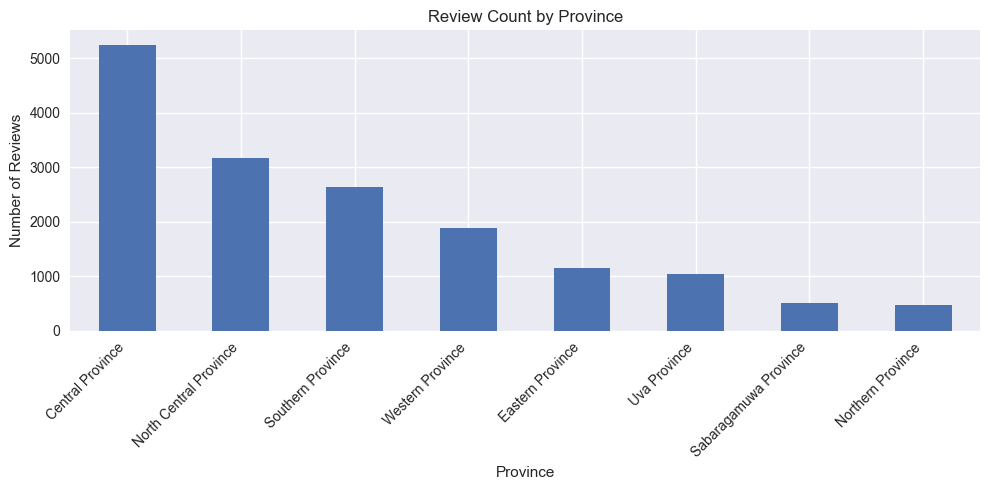

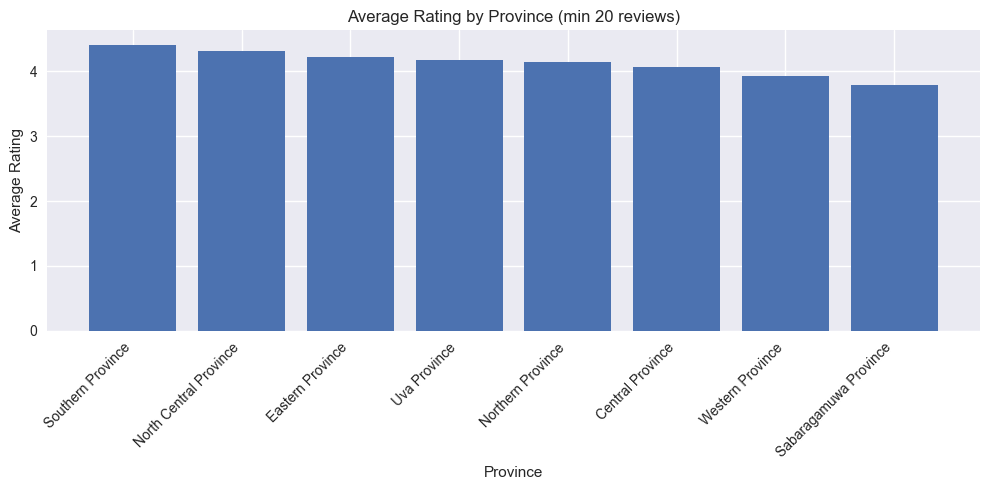

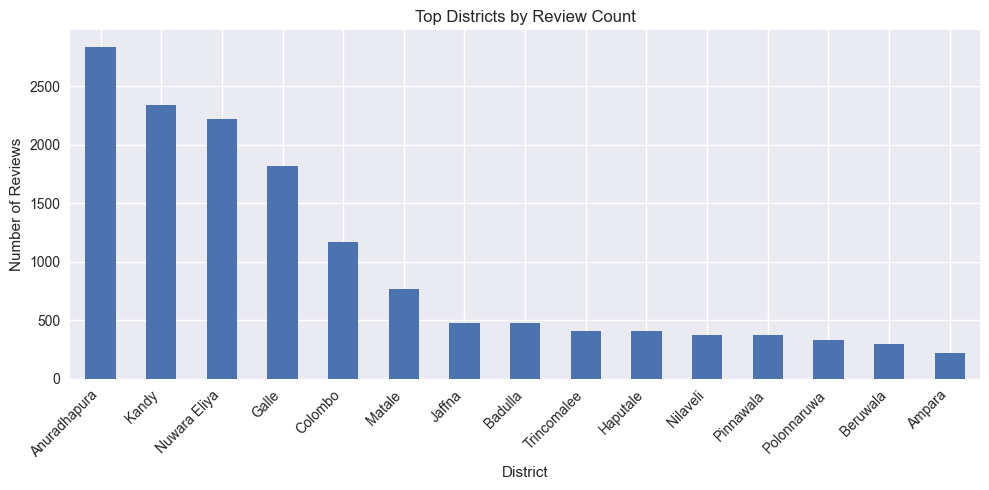

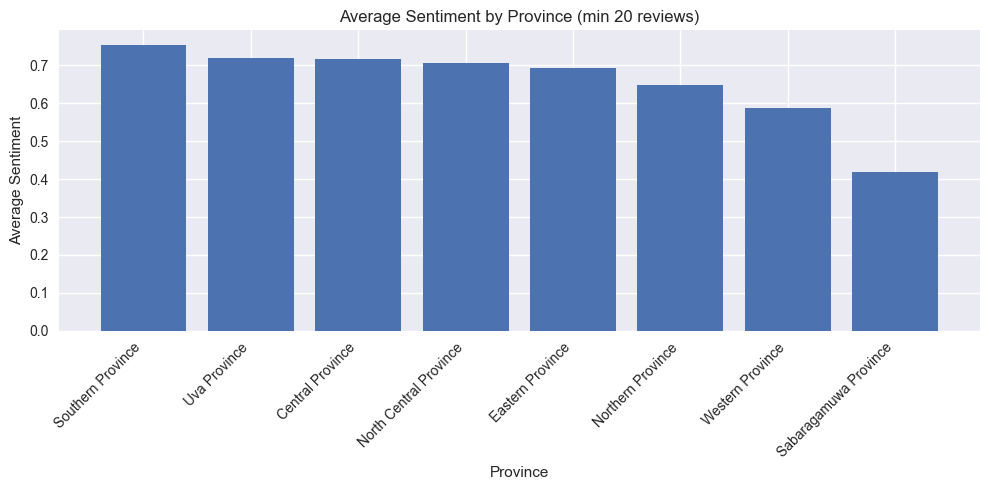

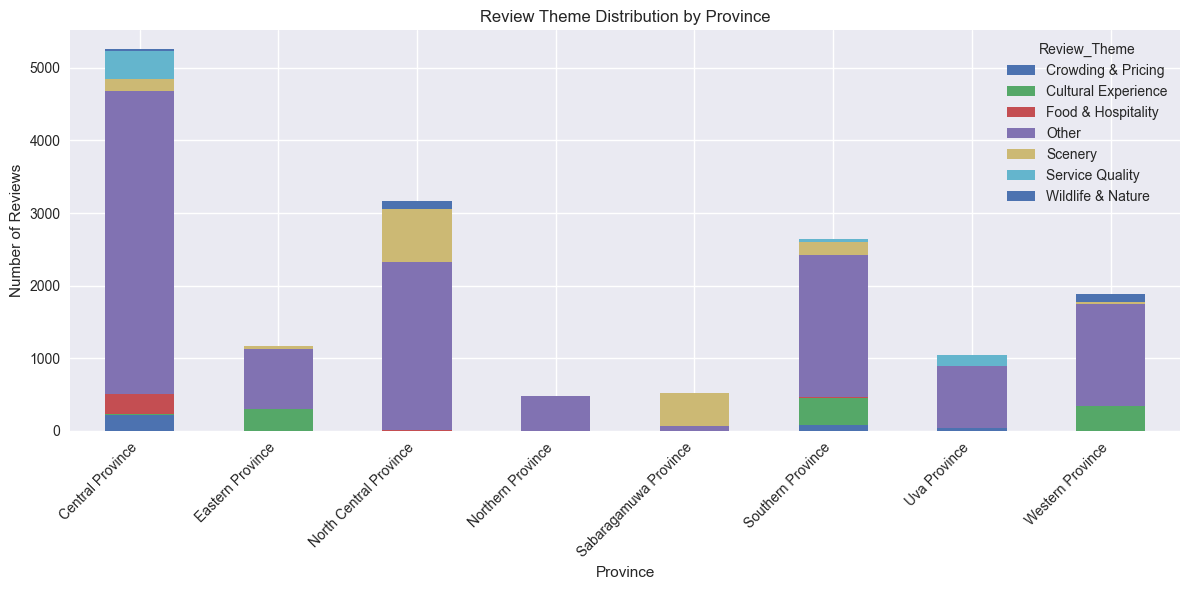

In [11]:
# Plots
plt.figure(figsize=(10, 5))
province_counts.plot(kind="bar")
plt.title("Review Count by Province")
plt.xlabel("Province")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

if not province_rating_summary.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(province_rating_summary["Province"], province_rating_summary["Avg_Rating"])
    plt.title(f"Average Rating by Province (min {MIN_REVIEWS_REGION} reviews)")
    plt.xlabel("Province")
    plt.ylabel("Average Rating")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(10, 5))
district_counts.plot(kind="bar")
plt.title("Top Districts by Review Count")
plt.xlabel("District")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

if province_sentiment_summary is not None and not province_sentiment_summary.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(province_sentiment_summary["Province"], province_sentiment_summary["Avg_Sentiment"])
    plt.title(f"Average Sentiment by Province (min {MIN_REVIEWS_REGION} reviews)")
    plt.xlabel("Province")
    plt.ylabel("Average Sentiment")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

if province_theme_crosstab is not None and not province_theme_crosstab.empty:
    province_theme_crosstab.plot(kind="bar", stacked=True, figsize=(12, 6))
    plt.title("Review Theme Distribution by Province")
    plt.xlabel("Province")
    plt.ylabel("Number of Reviews")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

In [12]:
# Save outputs
province_rating_summary.to_csv("province_rating_summary.csv", index=False)
district_rating_summary.to_csv("district_rating_summary.csv", index=False)
province_counts.to_csv("province_review_counts.csv")
district_counts.to_csv("district_review_counts.csv")

if province_sentiment_summary is not None:
    province_sentiment_summary.to_csv("province_sentiment_summary.csv", index=False)

if district_sentiment_summary is not None:
    district_sentiment_summary.to_csv("district_sentiment_summary.csv", index=False)

if province_theme_crosstab is not None:
    province_theme_crosstab.to_csv("province_theme_distribution.csv")

print("✅ Geographic analysis complete.")
print("Saved files:")
print("- province_rating_summary.csv")
print("- district_rating_summary.csv")
print("- province_review_counts.csv")
print("- district_review_counts.csv")
if province_sentiment_summary is not None:
    print("- province_sentiment_summary.csv")
if district_sentiment_summary is not None:
    print("- district_sentiment_summary.csv")
if province_theme_crosstab is not None:
    print("- province_theme_distribution.csv")

✅ Geographic analysis complete.
Saved files:
- province_rating_summary.csv
- district_rating_summary.csv
- province_review_counts.csv
- district_review_counts.csv
- province_sentiment_summary.csv
- district_sentiment_summary.csv
- province_theme_distribution.csv
